<div style="background-color: steelblue; padding: 10px; border-radius: 5px;">
    <p style="margin: 10;"></p>
    <h1 style="text-align: center; margin: 0; font-weight: bold; color: white;">SWOT OMIP : SWOT ratio</h1>
    <p style="margin: 10;"></p>
</div>


## 📦**Imports** 

In [3]:
%%time

##################################
#Imports

from datetime import datetime
import s3fs
import xarray as xr
import pyinterp
from widetrax import DataPreprocessing as dp
from widetrax import Spectra as sp
import numpy as np
import json
from watermark import watermark
import time
import platform
from shapely.geometry import shape, box

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import plot_psd1Xglobal1 as pp2X

CPU times: user 1.47 s, sys: 266 ms, total: 1.73 s
Wall time: 2.2 s


## **Load boxes position**

In [4]:
# CONFIG

# NOT MODIFY

roi = {
        "lon_min": -180,
        "lon_max": 180,
        "lat_min": -90,
        "lat_max": 90
}
pos_reg=[-180, -90, 180, 90]

with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

roi_poly = box(roi["lon_min"], roi["lat_min"],
               roi["lon_max"], roi["lat_max"])

selected = []

for feature in data["features"]:
    poly = shape(feature["geometry"])
    if poly.intersects(roi_poly):
        selected.append(poly)


north_boxes = []
south_boxes = []

for i, feature in enumerate(data["features"]):

    coords = feature["geometry"]["coordinates"][0]

    lats = [c[1] for c in coords]

    lat_center = sum(lats) / len(lats)

    if lat_center >= 0:
        north_boxes.append(i)
    else:
        south_boxes.append(i)

print("North boxes:", len(north_boxes))
print("South boxes:", len(south_boxes))
print(north_boxes)

North boxes: 93
South boxes: 189
[189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281]


## **Estimating the SWOT/Model ratio for both seasons**

In [6]:



#MODEL LOAD
models=["GLO12","GLO36","NOC12","NOC025","SWOT"]



box=0
psdsW=np.zeros((len(selected),4))
psdsS=np.zeros((len(selected),4))

for i, poly in enumerate(selected):

    if (i!=14) and (i!=15):
        season="JFM"
        spectrumJFM=[]
        freqJFM=[]
        # Plot spectrum JFM
        for imod in ["GLO12V4","GLO36V1","NOC12","NOC025"]:
            filename = "GLOBALv2/" + imod +  "/Global_box_" + str(box) + "_" + season + "_" + imod + ".json"
            with open(filename, "r") as f:
                data = json.load(f)
            spectrumJFM.append(data["Spectra"])
            freqJFM.append(data["Frequency"])

        season="JAS"
        spectrumJAS=[]
        freqJAS=[]
        # Plot spectrum JAS
        for imod in ["GLO12V4","GLO36V1","NOC12","NOC025"]:
            filename = "GLOBALv2/" + imod +  "/Global_box_" + str(box) + "_" + season + "_" + imod + ".json"
            with open(filename, "r") as f:
                data = json.load(f)
            spectrumJAS.append(data["Spectra"])
            freqJAS.append(data["Frequency"])

        season="JFM"
        spectrumSJFM=[]
        freqSJFM=[]
        # Plot spectrum JFM
        for imod in ["SWOT"]:
            filename = "GLOBALv2/" + imod +  "/Global_box_" + str(box) + "_" + season + "_" + imod + ".json"
            with open(filename, "r") as f:
                data = json.load(f)
            spectrumSJFM.append(data["Spectra"])
            freqSJFM.append(data["Frequency"])

        season="JAS"
        spectrumSJAS=[]
        freqSJAS=[]
        # Plot spectrum JAS
        for imod in ["SWOT"]:
            filename = "GLOBALv2/" + imod +  "/Global_box_" + str(box) + "_" + season + "_" + imod + ".json"
            with open(filename, "r") as f:
                data = json.load(f)
            spectrumSJAS.append(data["Spectra"])
            freqSJAS.append(data["Frequency"])

    

        wavelength=1/np.array(freqJFM)
 
        for imodel in range(4): 
            poswl=np.where((wavelength[imodel]>50) & (wavelength[imodel]<150))
            spectrumJFMM=spectrumJFM[imodel]
            spectrumJASM=spectrumJAS[imodel]
            if box in north_boxes:
                ratioW=(np.array(spectrumJFMM / np.where(spectrumSJAS == 0, np.nan, spectrumSJAS)))
                ratioS=(np.array(spectrumJASM / np.where(spectrumSJFM == 0, np.nan, spectrumSJFM)))
            elif box in south_boxes:
                ratioS=(np.array(spectrumJFMM / np.where(spectrumSJAS == 0, np.nan, spectrumSJAS)))
                ratioW=(np.array(spectrumJASM / np.where(spectrumSJFM == 0, np.nan, spectrumSJFM)))
            psdsW[box,imodel] = np.nanmean(ratioW[:,poswl[0]])
            psdsS[box,imodel] = np.nanmean(ratioS[:,poswl[0]])

            
        box=box+1

    else:
        box=box+1

with open("mostly_ocean_boxes_filtered.geojson") as f:
    data = json.load(f)

nboxes = len(data["features"])
    
lon_min_list = []
lat_min_list = []

for feature in data["features"]:
    coords = feature["geometry"]["coordinates"][0]
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]

    lon_min_list.append(min(lons))
    lat_min_list.append(min(lats))

lon_min_list = np.array(lon_min_list)
lat_min_list = np.array(lat_min_list)

lon_edges = np.arange(-180, 181, 10)
lat_edges = np.arange(-90, 91, 10)

nlon = len(lon_edges) - 1
nlat = len(lat_edges) - 1

ZW = np.full((4,nlat, nlon), np.nan)
values = np.array(psdsW)   # shape (280,)
for i in range(nboxes):
    lon_idx = np.where(lon_edges[:-1] == lon_min_list[i])[0][0]
    lat_idx = np.where(lat_edges[:-1] == lat_min_list[i])[0][0]
    for imodel in range(4):
        ZW[imodel,lat_idx, lon_idx] = np.array(values[i,imodel])

ZS = np.full((4,nlat, nlon), np.nan)
values = np.array(psdsS)   # shape (280,)
for i in range(nboxes):
    lon_idx = np.where(lon_edges[:-1] == lon_min_list[i])[0][0]
    lat_idx = np.where(lat_edges[:-1] == lat_min_list[i])[0][0]
    for imodel in range(4):
        ZS[imodel,lat_idx, lon_idx] = np.array(values[i,imodel])

/var/folders/c9/n_765b212hs2ss0sxlp635dr0000gp/T/ipykernel_5698/2356139926.py:59: RuntimeWarning: divide by zero encountered in divide
  wavelength=1/np.array(freqJFM)


## **Plotting**

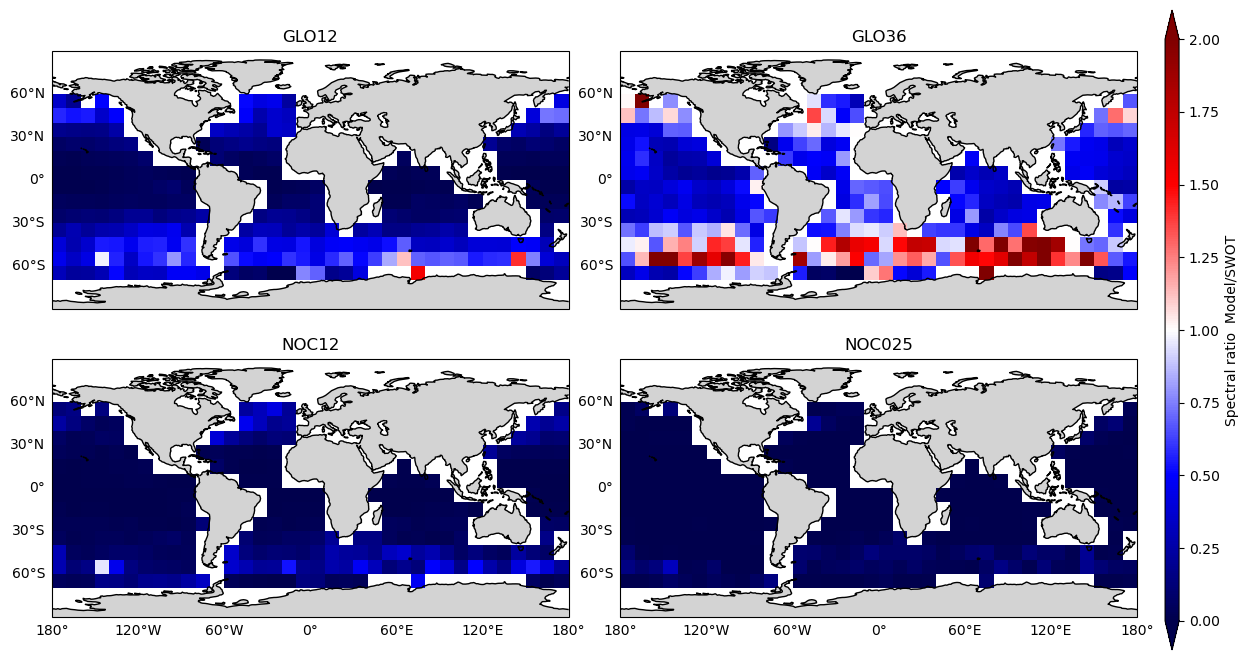

In [7]:
model= ["GLO12","GLO36","NOC12","NOC025","SWOT"]
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
cmap='seismic'
season="summer"
if season=="winter":
    Z=ZW
elif season=="summer":
    Z=ZS

valmin=0
valmax=2
fig, ax = plt.subplots(2, 2,figsize=(14, 8),subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(wspace=0.1, hspace=0)
#ax = plt.axes(projection=ccrs.PlateCarree())
imodel=0
ax[0,0].add_feature(cfeature.COASTLINE)
ax[0,0].add_feature(cfeature.LAND, facecolor="lightgray")
mesh = ax[0,0].pcolormesh(
    lon_edges,
    lat_edges,
    np.squeeze(Z[imodel,:,:]),
    vmin=valmin,
    vmax=valmax,
    cmap=cmap,
    transform=ccrs.PlateCarree()
)
ax[0,0].set_title(model[imodel])
ax[0,0] = ax[0,0].gridlines(draw_labels=True,linewidth=0.2)
ax[0,0].bottom_labels = False
ax[0,0].top_labels = False
ax[0,0].right_labels = False
ax[0,0].left_labels = True
ax[0,0].xlines = False
ax[0,0].ylines = False

#------
imodel=1
ax[0,1].add_feature(cfeature.COASTLINE)
ax[0,1].add_feature(cfeature.LAND, facecolor="lightgray")
mesh = ax[0,1].pcolormesh(
    lon_edges,
    lat_edges,
    np.squeeze(Z[imodel,:,:]),
    vmin=valmin,
    vmax=valmax,
    cmap=cmap,
    transform=ccrs.PlateCarree()
)
ax[0,1].set_title(model[imodel])
ax[0,1] = ax[0,1].gridlines(draw_labels=True,linewidth=0.2)
ax[0,1].bottom_labels = False
ax[0,1].top_labels = False
ax[0,1].right_labels = False
ax[0,1].left_labels = True
ax[0,1].xlines = False
ax[0,1].ylines = False


#-----------
imodel=2
ax[1,0].add_feature(cfeature.COASTLINE)
ax[1,0].add_feature(cfeature.LAND, facecolor="lightgray")
mesh = ax[1,0].pcolormesh(
    lon_edges,
    lat_edges,
    np.squeeze(Z[imodel,:,:]),
    vmin=valmin,
    vmax=valmax,
    cmap=cmap,
    transform=ccrs.PlateCarree()
)
ax[1,0].set_title(model[imodel])
ax[1,0] = ax[1,0].gridlines(draw_labels=True,linewidth=0.2)
ax[1,0].bottom_labels = True
ax[1,0].top_labels = False
ax[1,0].right_labels = False
ax[1,0].left_labels = True
ax[1,0].xlines = False
ax[1,0].ylines = False

#----------
imodel=3
ax[1,1].add_feature(cfeature.COASTLINE)
ax[1,1].add_feature(cfeature.LAND, facecolor="lightgray")
mesh = ax[1,1].pcolormesh(
    lon_edges,
    lat_edges,
    np.squeeze(Z[imodel,:,:]),
    vmin=valmin,
    vmax=valmax,
    cmap=cmap,
    transform=ccrs.PlateCarree()
)
ax[1,1].set_title(model[imodel])
ax[1,1] = ax[1,1].gridlines(draw_labels=True,linewidth=0.2)
ax[1,1].bottom_labels = True
ax[1,1].top_labels = False
ax[1,1].right_labels = False
ax[1,1].left_labels = True
ax[1,1].xlines = False
ax[1,1].ylines = False

#----------


#plt.colorbar(mesh, ax=ax[0,0], orientation="vertical")
cbar_ax = fig.add_axes([0.92, 0.1, 0.01, .8])
cbar = fig.colorbar(mesh,cax=cbar_ax, orientation='vertical', fraction=0.02,  extend='both')
cbar.set_label("Spectral ratio  Model/SWOT")
plt.savefig("Fig/ratio_season_model"+season+".png",dpi=300,transparent=False)
plt.show()

In [10]:

Z=ZS
box_pos=np.zeros((4))
box_neg=np.zeros((4))

for imodel in range(4):
    box_neg[imodel]=len(np.where(Z[imodel,:,:]<1)[0])
    box_pos[imodel]=len(np.where(Z[imodel,:,:]>1)[0])

print(box_pos)
print(box_neg)


[ 3. 64.  0.  0.]
[279. 218. 282. 282.]
